In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

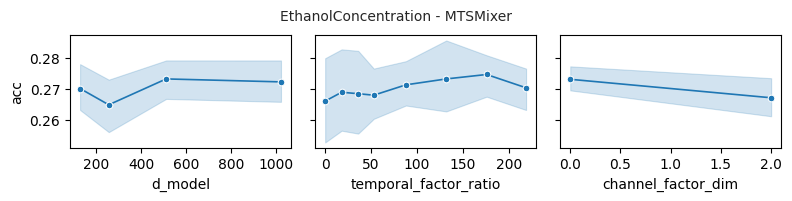

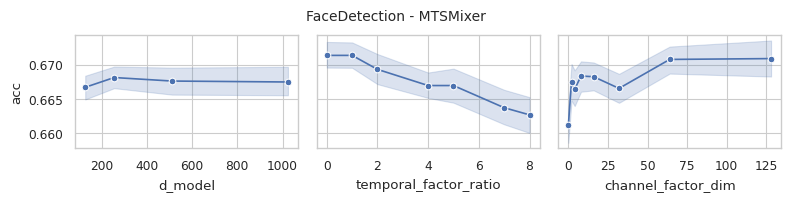

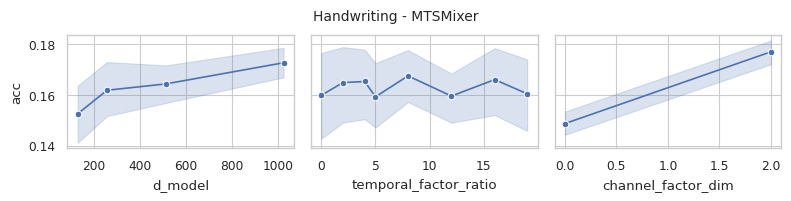

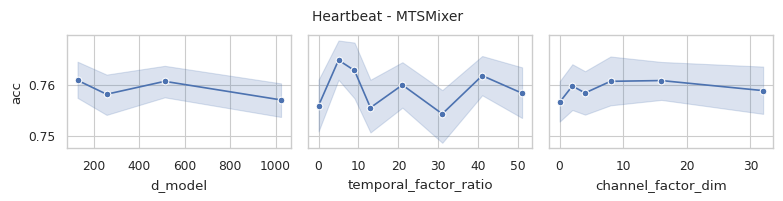

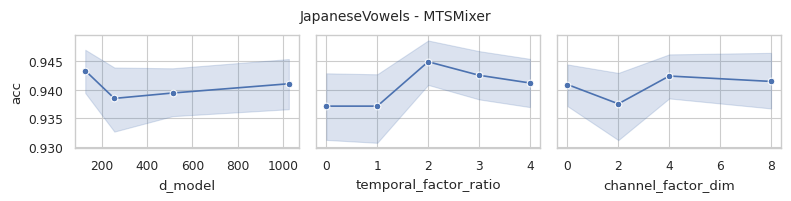

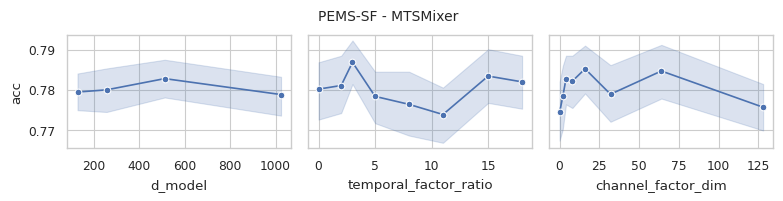

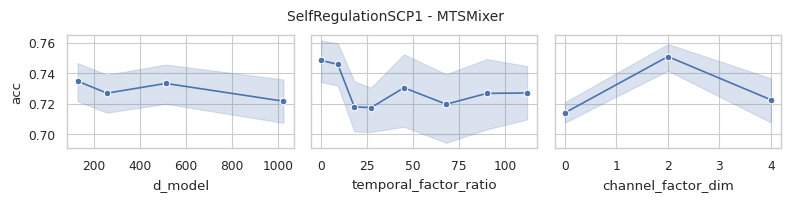

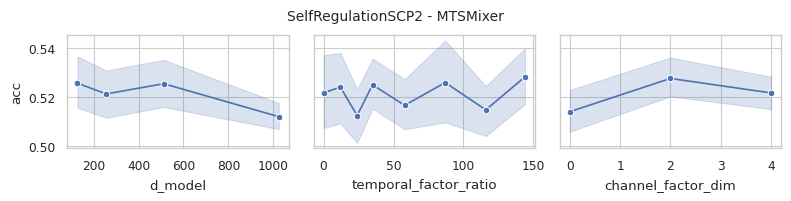

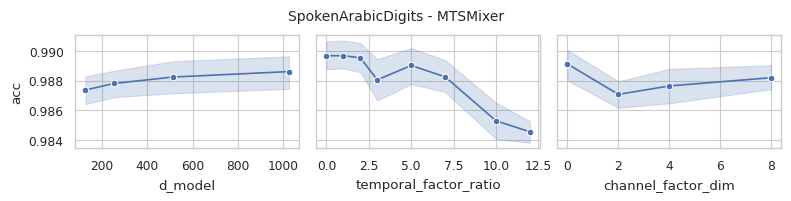

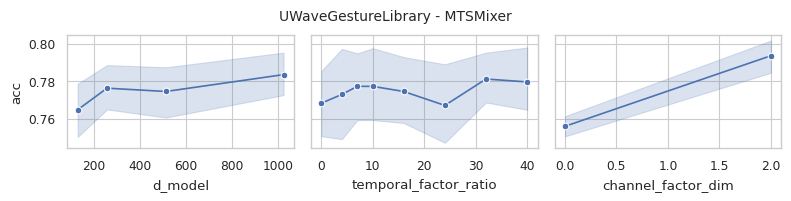

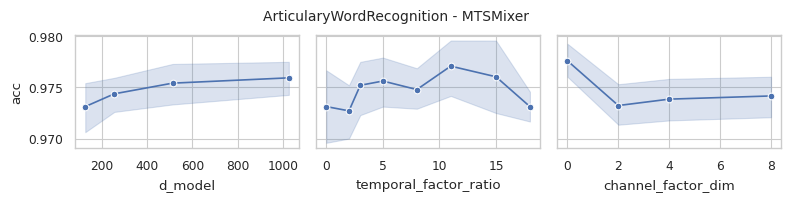

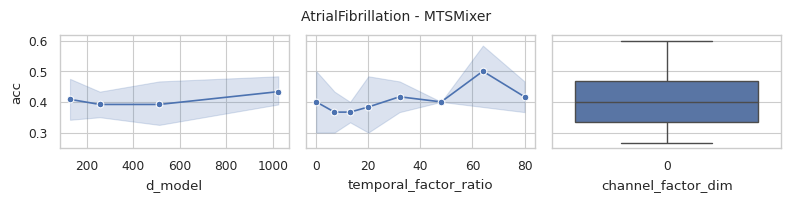

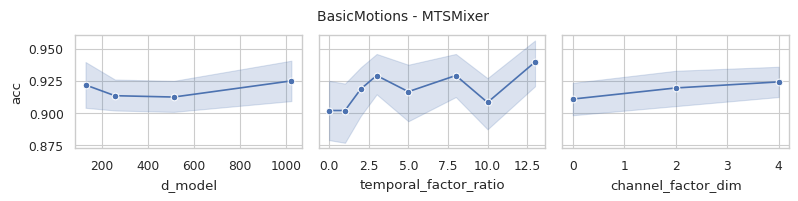

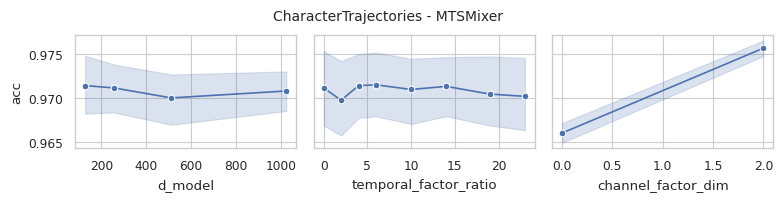

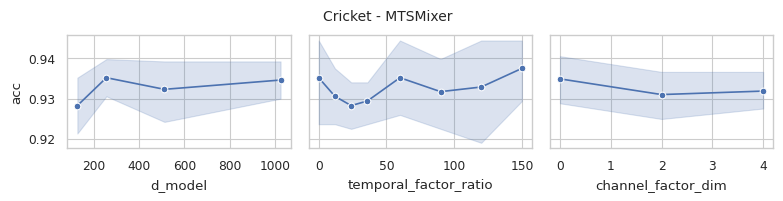

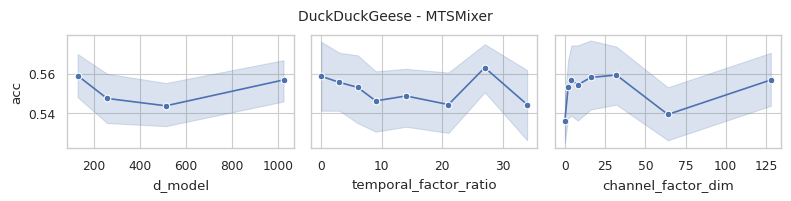

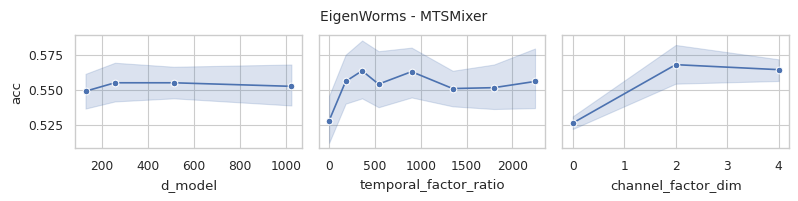

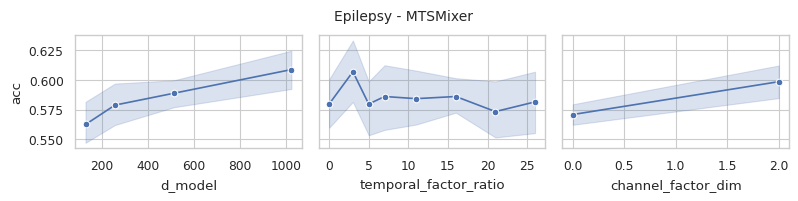

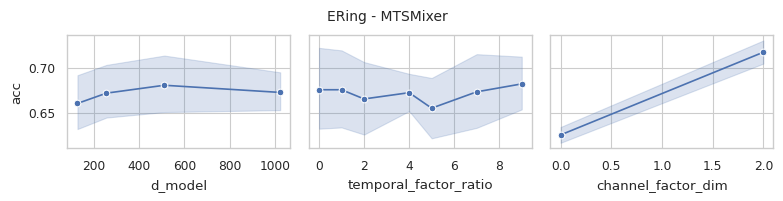

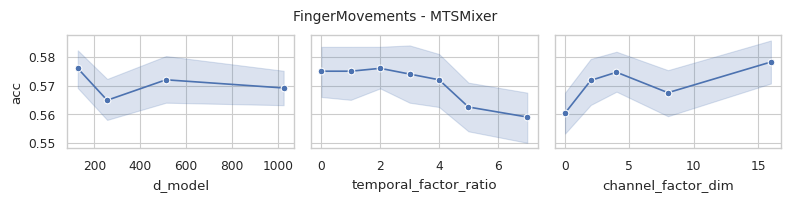

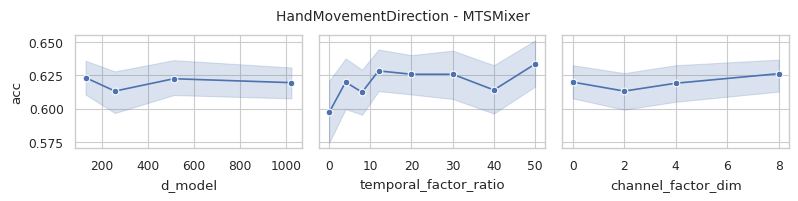

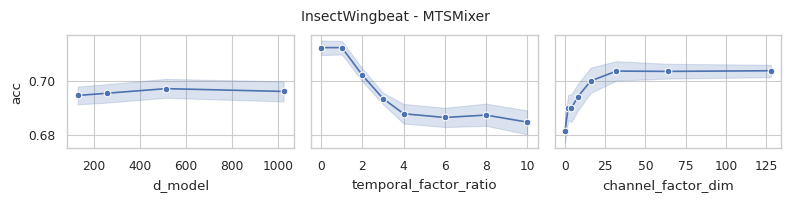

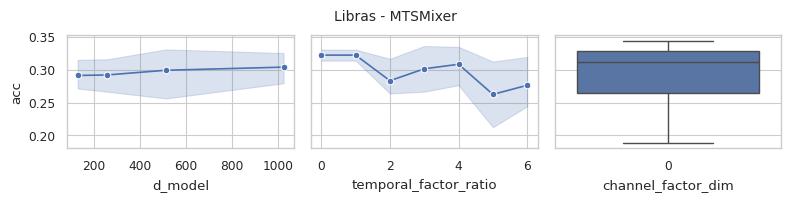

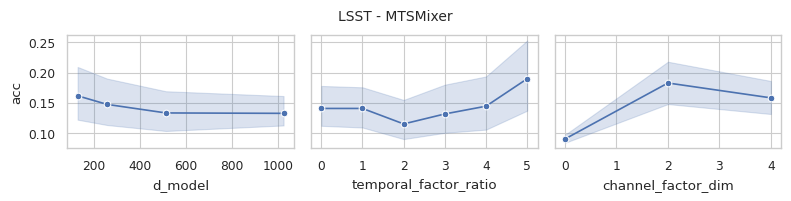

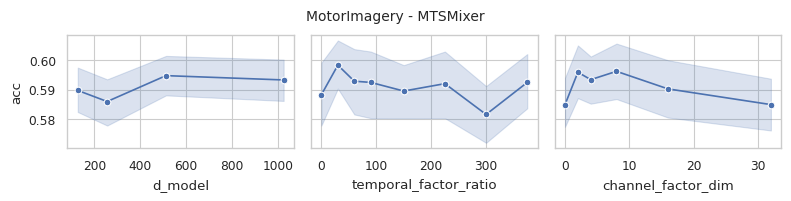

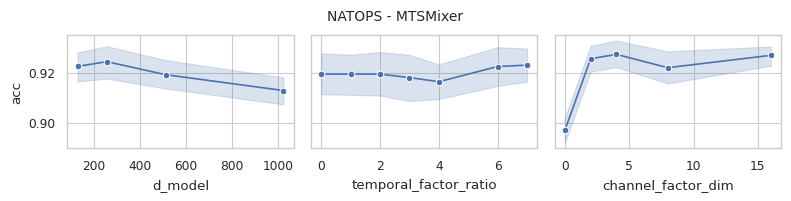

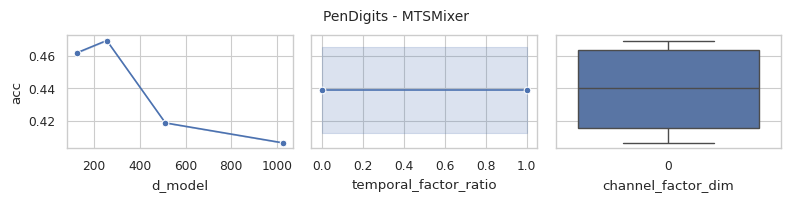

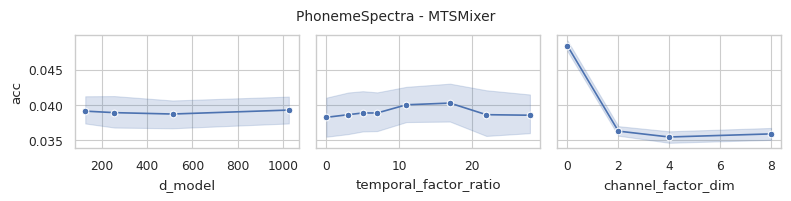

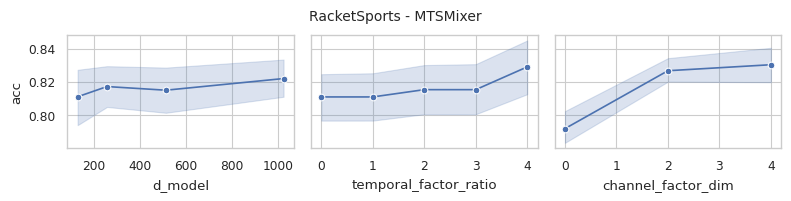

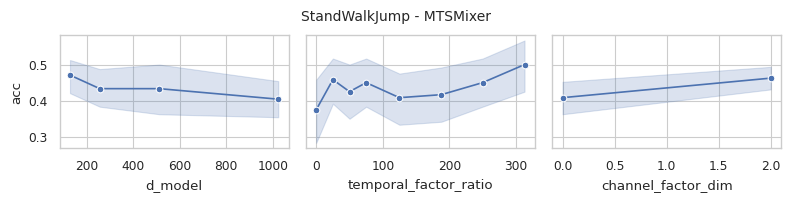

In [4]:
model = 'MTSMixer'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('el', ''))
            data_meta[10] = int(data_meta[10].replace('dm', ''))
            data_meta[11] = bool(int(data_meta[11].replace('fT', '')))
            data_meta[12] = int(data_meta[12].replace('w', ''))
            data_meta[13] = bool(int(data_meta[13].replace('fC', '')))
            data_meta[14] = int(data_meta[14].replace('df', ''))
            data_meta[15] = bool(int(data_meta[15].replace('rev', '')))
            data_meta[16] = bool(int(data_meta[16].replace('n', '')))
            data_meta[17] = bool(int(data_meta[17].replace('i', '')))


            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'model_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'n_layers': data_meta[9],
                'd_model': data_meta[10],
                'use_temporal_interaction': data_meta[11],
                'temporal_factor_ratio': data_meta[12],
                'use_channel_interaction': data_meta[13],
                'channel_factor_dim': data_meta[14],
                'revIn': data_meta[15],
                'norm': data_meta[16],
                'individual': data_meta[17],
                # 'exp': data_meta[18],
                # 'desc': data_meta[19],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['d_model', 'temporal_factor_ratio', 'channel_factor_dim']
    num_cols, num_rows = 3, 1
    
    # # Boxplot
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False, style='model', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    

In [5]:
model_configs = {
    "d_model" : [128, 256, 512, 1024],
    "e_layers" : [2],

    # 0 means fac_C is False, else fac_C is True
    "channel_factor_dim" : [0, 2, 4, 8, 16, 32, 64, 128],

    # 0 means fac_T is False, else fac_T is True
    "temporal_factor_ratio": [0, 1, 2, 3, 5, 7.5, 10, 12.5,],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        d_model = hyperparameter_combination['d_model']
        n_layers = hyperparameter_combination['e_layers']
        d_facC = hyperparameter_combination['channel_factor_dim']
        d_facT_ratio = hyperparameter_combination['temporal_factor_ratio']

        d_facT = math.ceil((d_facT_ratio/100) * seq_len)
        fac_T = bool(d_facT)
        
        while d_facC > enc_in:
            d_facC //= 2
        if d_facC == enc_in:
            d_facC = 0
        fac_C = bool(d_facC)
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['d_model'] == d_model)
                & (tmp['n_layers'] == n_layers)
                & (tmp['use_temporal_interaction'] == fac_T)
                & (tmp['temporal_factor_ratio'] == d_facT)
                & (tmp['use_channel_interaction'] == fac_C)
                & (tmp['channel_factor_dim'] == d_facC)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 16, 'temporal_factor_ratio': 1}","{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 32, 'temporal_factor_ratio': 1}","{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 8, 'temporal_factor_ratio': 1}","{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 128, 'temporal_factor_ratio': 1}","{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 4, 'temporal_factor_ratio': 1}","{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 64, 'temporal_factor_ratio': 1}","{'d_model': 256, 'e_layers': 2, 'channel_factor_dim': 32, 'temporal_factor_ratio': 12.5}","{'d_model': 256, 'e_layers': 2, 'channel_factor_dim': 4, 'temporal_factor_ratio': 12.5}","{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 2, 'temporal_factor_ratio': 10}",...,"{'d_model': 256, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 7.5}","{'d_model': 256, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 3}","{'d_model': 256, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 0}","{'d_model': 256, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 2}","{'d_model': 256, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 1}","{'d_model': 512, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 0}","{'d_model': 1024, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 5}","{'d_model': 512, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 7.5}","{'d_model': 1024, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 0}","{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 0, 'temporal_factor_ratio': 2}"
EthanolConcentration,0.307985,0.304183,0.304183,0.304183,0.304183,0.304183,0.304183,0.247148,0.247148,0.285171,...,0.277567,0.273764,0.26616,0.262357,0.285171,0.262357,0.258555,0.277567,0.273764,0.296578
FaceDetection,0.685301,0.670545,0.666572,0.674518,0.667707,0.668275,0.668275,0.674234,0.662316,0.675085,...,0.657775,0.652951,0.667707,0.652951,0.667707,0.66714,0.659478,0.661748,0.665437,0.659478
Handwriting,0.196471,0.188235,0.188235,0.188235,0.188235,0.188235,0.188235,0.181176,0.181176,0.184706,...,0.155294,0.138824,0.136471,0.148235,0.145882,0.144706,0.170588,0.157647,0.170588,0.128235
Heartbeat,0.790244,0.780488,0.77561,0.77561,0.77561,0.77561,0.77561,0.756098,0.75122,0.75122,...,0.75122,0.75122,0.756098,0.785366,0.770732,0.75122,0.736585,0.760976,0.746341,0.75122
JapaneseVowels,0.959459,0.948649,0.948649,0.948649,0.948649,0.951351,0.948649,0.959459,0.943243,0.940541,...,0.945946,0.943243,0.943243,0.943243,0.943243,0.945946,0.948649,0.932432,0.924324,0.951351
PEMS-SF,0.820809,0.751445,0.757225,0.797688,0.757225,0.803468,0.780347,0.815029,0.791908,0.791908,...,0.786127,0.768786,0.722543,0.786127,0.797688,0.780347,0.768786,0.739884,0.757225,0.751445
SelfRegulationSCP1,0.788396,0.740614,0.740614,0.740614,0.740614,0.740614,0.740614,0.757679,0.757679,0.767918,...,0.703072,0.720137,0.730375,0.706485,0.699659,0.757679,0.740614,0.696246,0.703072,0.696246
SelfRegulationSCP2,0.583333,0.5,0.5,0.5,0.5,0.5,0.5,0.505556,0.505556,0.477778,...,0.466667,0.5,0.544444,0.488889,0.494444,0.5,0.5,0.511111,0.494444,0.5
SpokenArabicDigits,0.994543,0.986812,0.986812,0.986812,0.986812,0.989086,0.986812,0.986812,0.984084,0.981355,...,0.987267,0.992724,0.990905,0.990905,0.990905,0.989541,0.989995,0.99045,0.99136,0.992269
UWaveGestureLibrary,0.83125,0.80625,0.80625,0.80625,0.80625,0.80625,0.80625,0.7625,0.7625,0.8125,...,0.759375,0.759375,0.75625,0.765625,0.7375,0.7375,0.7625,0.765625,0.75625,0.73125


In [7]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'d_model': 128, 'e_layers': 2, 'channel_factor_dim': 16, 'temporal_factor_ratio': 1}"
EthanolConcentration,30.79847908745247,30.41825095057034
FaceDetection,68.53007945516458,67.05448354143019
Handwriting,19.64705882352941,18.82352941176471
Heartbeat,79.02439024390245,78.04878048780488
JapaneseVowels,95.94594594594594,94.86486486486486
PEMS-SF,82.08092485549133,75.14450867052022
SelfRegulationSCP1,78.83959044368601,74.06143344709898
SelfRegulationSCP2,58.33333333333334,50.0
SpokenArabicDigits,99.45429740791269,98.681218735789
UWaveGestureLibrary,83.125,80.625
